In [21]:
import sys
print(sys.executable)

c:\Users\balud\character-recognition-nn\venv\Scripts\python.exe


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
print("numpy:", np.__version__)
print("pillow:", Image.__version__)
print("matplotlib:", plt.matplotlib.__version__)

numpy: 2.5.3
pillow: 12.3.0
matplotlib: 3.11.1


In [23]:
import matplotlib.font_manager as fm

font_paths = [f.fname for f in fm.fontManager.ttflist if f.fname.endswith(('.ttf', '.otf'))]
print(f"Total font files found: {len(font_paths)}")

names = set()
for path in font_paths:
    try:
        names.add(fm.FontProperties(fname=path).get_name())
    except Exception:
        pass
print(f"Unique font families: {len(names)}")
print(sorted(names))

Total font files found: 191
Unique font families: 79
['Arial', 'Bahnschrift', 'Calibri', 'Cambria', 'Camera Obscura', 'Candara', 'Comic Sans MS', 'Consolas', 'Constantia', 'Corbel', 'Courier New', 'DejaVu Sans', 'DejaVu Sans Display', 'DejaVu Sans Mono', 'DejaVu Serif', 'DejaVu Serif Display', 'Ebrima', 'Franklin Gothic Medium', 'Gabriola', 'Gadugi', 'Georgia', 'Headliner No. 45', 'Impact', 'Ink Free', 'Javanese Text', 'Last Resort High-Efficiency', 'Leelawadee UI', 'Long Cool Grandma', 'Lucida Console', 'Lucida Sans Unicode', 'MV Boli', 'Malgun Gothic', 'Microsoft Himalaya', 'Microsoft New Tai Lue', 'Microsoft PhagsPa', 'Microsoft Sans Serif', 'Microsoft Tai Le', 'Microsoft Yi Baiti', 'Mongolian Baiti', 'Myanmar Text', 'Palatino Linotype', 'Roman SD', 'STIXGeneral', 'STIXNonUnicode', 'STIXSizeFiveSym', 'STIXSizeFourSym', 'STIXSizeOneSym', 'STIXSizeThreeSym', 'STIXSizeTwoSym', 'Sans Serif Collection', 'Segoe Fluent Icons', 'Segoe MDL2 Assets', 'Segoe Print', 'Segoe Script', 'Segoe UI',

In [24]:
EXCLUDE_FONTS = {
    'Wingdings', 'Webdings', 'Segoe Fluent Icons', 'Segoe MDL2 Assets',
    'Segoe UI Symbol', 'Segoe UI Emoji', 'Symbol',
    'Ebrima', 'Javanese Text', 'Leelawadee UI', 'Malgun Gothic',
    'Microsoft Himalaya', 'Microsoft New Tai Lue', 'Microsoft PhagsPa',
    'Microsoft Tai Le', 'Microsoft Yi Baiti', 'Mongolian Baiti',
    'Myanmar Text', 'SimSun-ExtB', 'SimSun-ExtG', 'Sylfaen', 'Gadugi',
    'STIXGeneral', 'STIXNonUnicode', 'STIXSizeFiveSym', 'STIXSizeFourSym',
    'STIXSizeOneSym', 'STIXSizeThreeSym', 'STIXSizeTwoSym',
    'cmb10', 'cmex10', 'cmmi10', 'cmr10', 'cmss10', 'cmsy10', 'cmti10', 'cmtt10',
    'Gabriola', 'Segoe Script', 'Segoe Print', 'Camera Obscura',
    'Headliner No. 45', 'Long Cool Grandma', 'Roman SD', 'Typo-Longest Thin Demo',
}

font_paths_named = []
for path in font_paths:
    try:
        name = fm.FontProperties(fname=path).get_name()
        if name not in EXCLUDE_FONTS:
            font_paths_named.append((name, path))
    except Exception:
        continue

# De-duplicate by family name, keep first occurrence
seen = set()
fonts = []
for name, path in font_paths_named:
    if name not in seen:
        seen.add(name)
        fonts.append(path)

print(f"Final usable fonts: {len(fonts)}")

Final usable fonts: 34


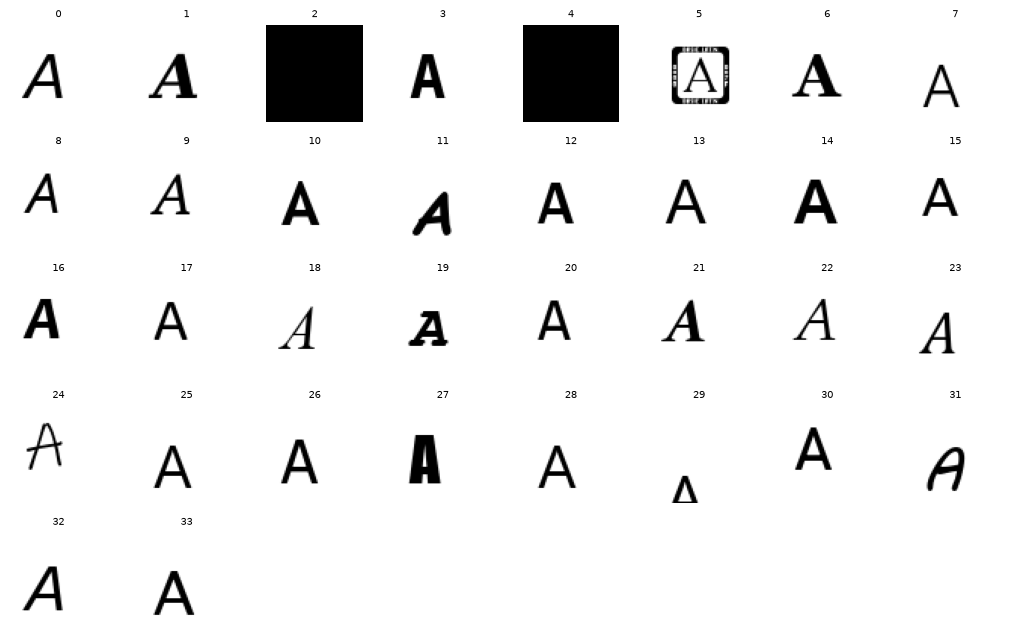

In [27]:
cols = 8
rows = (len(fonts) // cols) + 1
fig, axes = plt.subplots(rows, cols, figsize=(cols*1.3, rows*1.3))
axes = axes.flatten()

for i, font_path in enumerate(fonts):
    img = Image.new('L', (64, 64), color=255)
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype(font_path, 40)
        draw.text((10, 10), 'A', fill=0, font=font)
    except Exception:
        pass
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(str(i), fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [29]:
bad_indices = [2, 4, 5, 29]
fonts = [f for i, f in enumerate(fonts) if i not in bad_indices]
print(f"Fonts remaining after visual cleanup: {len(fonts)}")

Fonts remaining after visual cleanup: 26


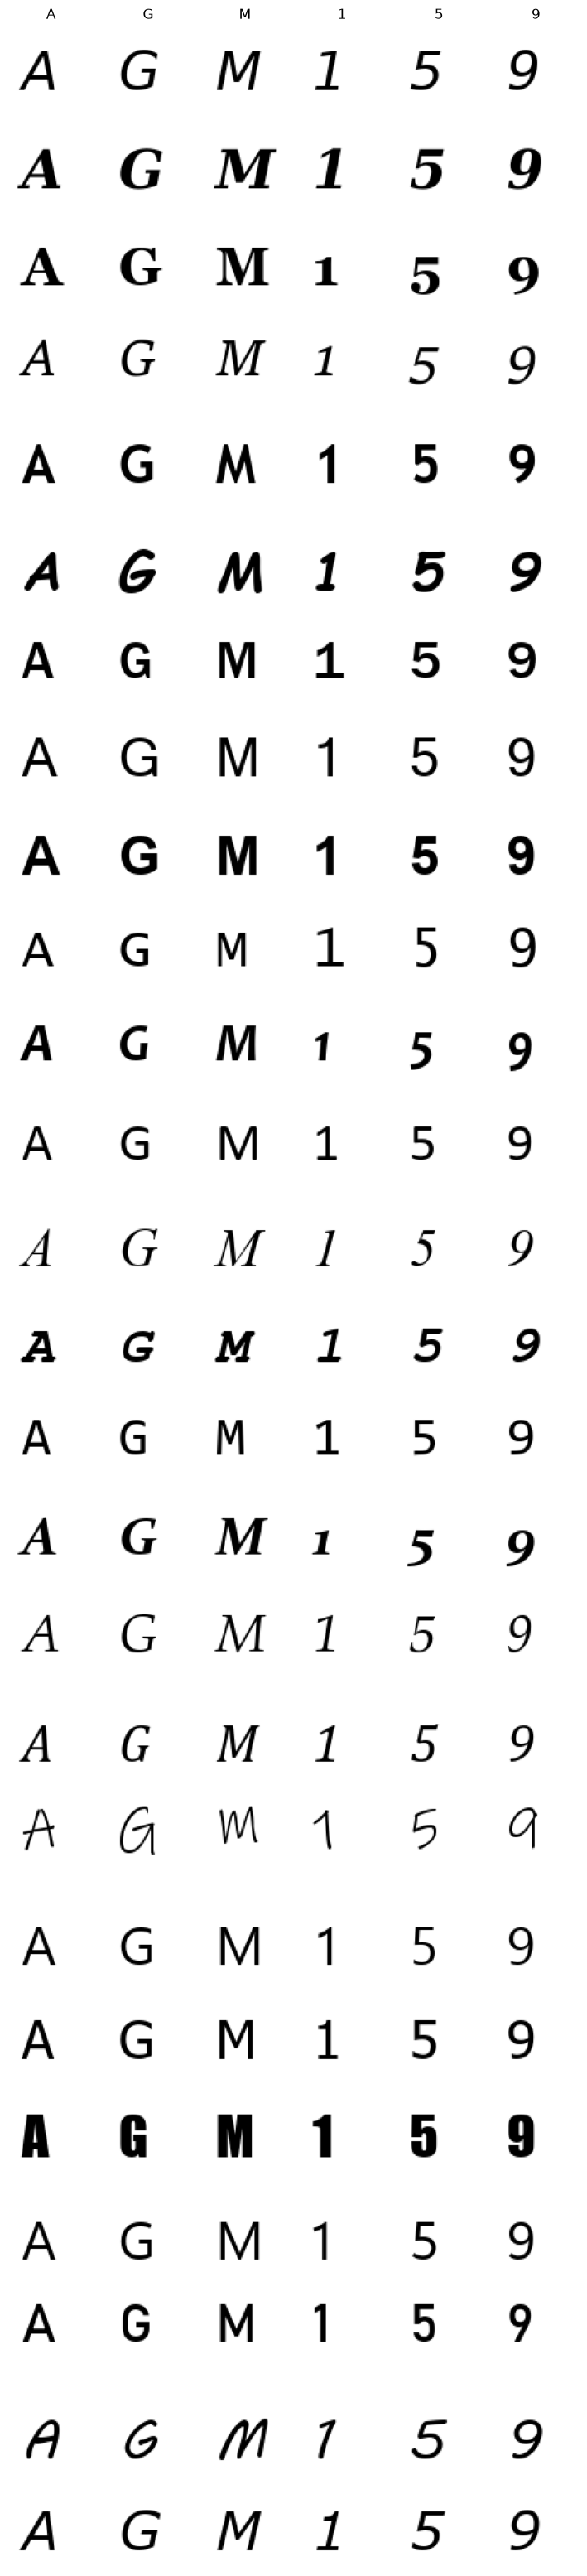

In [31]:
test_chars = ['A', 'G', 'M', '1', '5', '9']
fig, axes = plt.subplots(len(fonts), len(test_chars), figsize=(len(test_chars)*1.2, len(fonts)*1.2))

for i, font_path in enumerate(fonts):
    for j, ch in enumerate(test_chars):
        img = Image.new('L', (64, 64), color=255)
        draw = ImageDraw.Draw(img)
        try:
            font = ImageFont.truetype(font_path, 40)
            draw.text((10, 10), ch, fill=0, font=font)
        except Exception:
            pass
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(ch)

plt.tight_layout()
plt.show()

In [32]:
print(f"Final locked-in font count: {len(fonts)}")

Final locked-in font count: 26
